# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [2]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [5]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
df_fatalities.shape





(29268, 7)

In [13]:
df_pct_poverty.shape
df_share_race_city.shape

(29268, 7)

In [14]:

df_hh_income.shape


(29322, 3)

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [22]:
#check for the NaN values
print(df_fatalities.isnull())
print(df_hh_income.isnull())
print(df_pct_completed_hs.isnull())
print(df_share_race_city.isnull())
print(df_pct_poverty.isnull())

         id   name   date  manner_of_death  armed    age  gender   race  \
0     False  False  False            False  False  False   False  False   
1     False  False  False            False  False  False   False  False   
2     False  False  False            False  False  False   False  False   
3     False  False  False            False  False  False   False  False   
4     False  False  False            False  False  False   False  False   
...     ...    ...    ...              ...    ...    ...     ...    ...   
2530  False  False  False            False  False  False   False   True   
2531  False  False  False            False  False   True   False   True   
2532  False  False  False            False  False  False   False   True   
2533  False  False  False            False  False  False   False  False   
2534  False  False  False            False  False  False   False  False   

       city  state  signs_of_mental_illness  threat_level   flee  body_camera  
0     False  False 

In [43]:
#duplicates from the dataset
df_pct_poverty.duplicated().value_counts()
df_fatalities.duplicated().value_counts()
df_pct_completed_hs.duplicated().value_counts()
df_hh_income.duplicated().value_counts()
df_share_race_city.duplicated().value_counts()
df_share_race_city

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3
...,...,...,...,...,...,...,...
29263,WY,Woods Landing-Jelm CDP,95.9,0,0,2.1,0
29264,WY,Worland city,89.9,0.3,1.3,0.6,16.6
29265,WY,Wright town,94.5,0.1,1.4,0.2,6.2
29266,WY,Yoder town,97.4,0,0,0,4


In [40]:
#not for the overlap of data, we will remove duplicates
df_share_race_city.drop_duplicates(inplace=True)
df_share_race_city
df_fatalities.drop_duplicates(inplace=True)
df_hh_income.drop_duplicates(inplace=True)
df_pct_completed_hs.drop_duplicates(inplace=True)
df_pct_poverty.drop_duplicates(inplace=True)
df_pct_poverty

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.80
1,AL,Abbeville city,29.10
2,AL,Adamsville city,25.50
3,AL,Addison town,30.70
4,AL,Akron town,42.00
...,...,...,...
29324,WY,Woods Landing-Jelm CDP,18.60
29325,WY,Worland city,15.30
29326,WY,Wright town,5.90
29327,WY,Yoder town,5.40


In [41]:
#specific cleaning - har bar kahi numbers mai hyphen aan (-) usko numeric mai change krna(numeric column)
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'],errors = 'coerce').fillna(0)
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'],errors = 'coerce').fillna(0)
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'],errors='coerce').fillna(0)
df_pct_completed_hs


,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.20
1,AL,Abbeville city,69.10
2,AL,Adamsville city,78.90
3,AL,Addison town,81.40
4,AL,Akron town,68.60
...,...,...,...
29324,WY,Woods Landing-Jelm CDP,100.00
29325,WY,Worland city,85.60
29326,WY,Wright town,89.20
29327,WY,Yoder town,79.40


In [42]:
df_fatalities['race'] = df_fatalities['race'].fillna('U') # 'U' for Unknown
df_fatalities['age'] = df_fatalities['age'].fillna(df_fatalities['age'].median())# for age median is best
df_fatalities

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,U,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,34.00,M,U,Albuquerque,NM,False,attack,Car,False
2532,2818,Dennis W. Robinson,29/07/17,shot,gun,48.00,M,U,Melba,ID,False,attack,Car,False
2533,2817,Isaiah Tucker,31/07/17,shot,vehicle,28.00,M,B,Oshkosh,WI,False,attack,Car,True


In [38]:
#check for total missing values
print(df_fatalities.isnull().sum())
df_fatalities

id                          0
name                        0
date                        0
manner_of_death             0
armed                       9
age                         0
gender                      0
race                        0
city                        0
state                       0
signs_of_mental_illness     0
threat_level                0
flee                       65
body_camera                 0
dtype: int64


,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,U,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,34.00,M,U,Albuquerque,NM,False,attack,Car,False
2532,2818,Dennis W. Robinson,29/07/17,shot,gun,48.00,M,U,Melba,ID,False,attack,Car,False
2533,2817,Isaiah Tucker,31/07/17,shot,vehicle,28.00,M,B,Oshkosh,WI,False,attack,Car,True


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [46]:
#to convert poverty rate in numeric value
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'],errors='coerce')
#to drop NaN  and fill 0
df_pct_poverty.dropna(subset=['poverty_rate'],inplace=True)
#state wise(geographically-area)to find average of state wise and sort them 
state_poverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False)


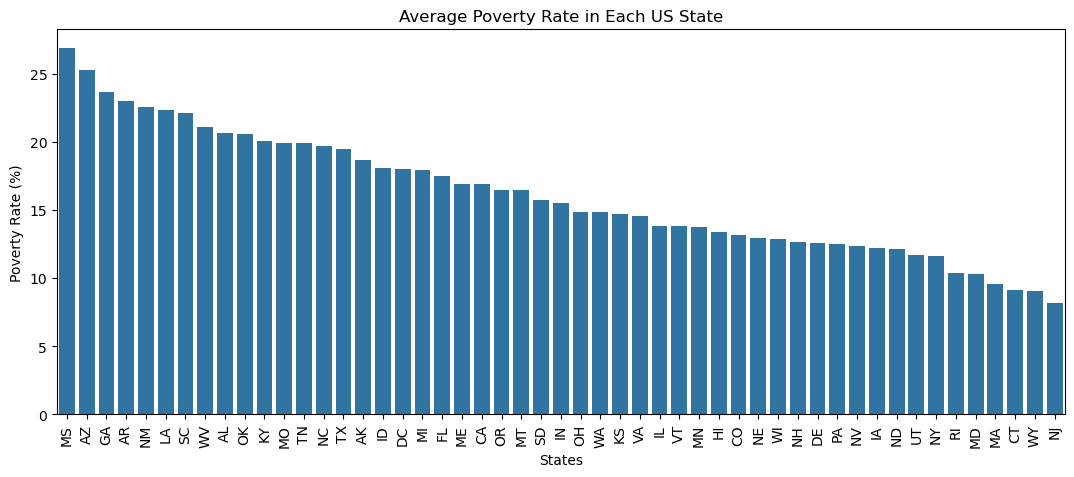

In [53]:
plt.figure(figsize=(13,5))
sns.barplot(x = state_poverty.index,
            y = state_poverty.values)
plt.xticks(rotation = 90) #to show the states name in vertical direction
plt.xlabel('States')
plt.ylabel('Poverty Rate (%)')
plt.title('Average Poverty Rate in Each US State')
plt.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [55]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'],errors = 'coerce')# to change dataset into numeric like NaN
# drop NaN IN 0
df_pct_completed_hs.dropna(subset=['percent_completed_hs'],inplace = True)
# to depict statewise avg and sord them ascending accordinglly
states_hs_grad = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=False)


C:\Users\divya\AppData\Local\Temp\ipykernel_17024\3122764959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = states_hs_grad.index,


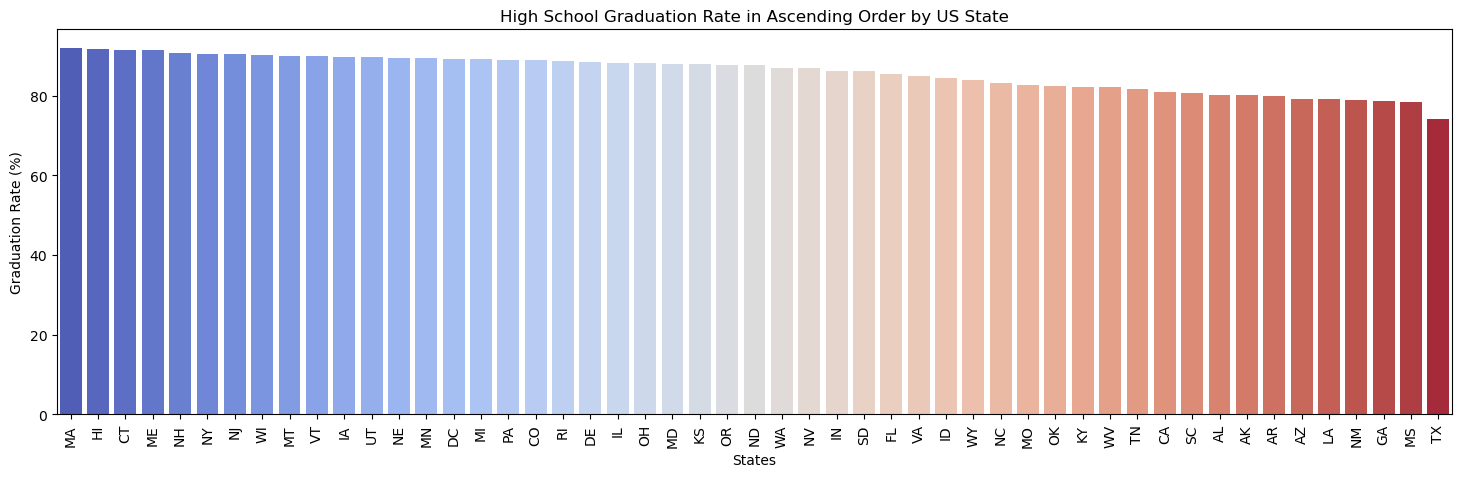

In [59]:
plt.figure(figsize=(18,5))
sns.barplot(x = states_hs_grad.index,
            y = states_hs_grad.values,
            palette='coolwarm')

plt.xticks(rotation = 90)
plt.xlabel('States')
plt.ylabel('Graduation Rate (%)')
plt.title('High School Graduation Rate in Ascending Order by US State')
plt.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [63]:
#data cleaning
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'],errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'],errors='coerce')

#dipict state wise average and match index
state_poverty = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_index()
states_hs_grad = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_index()

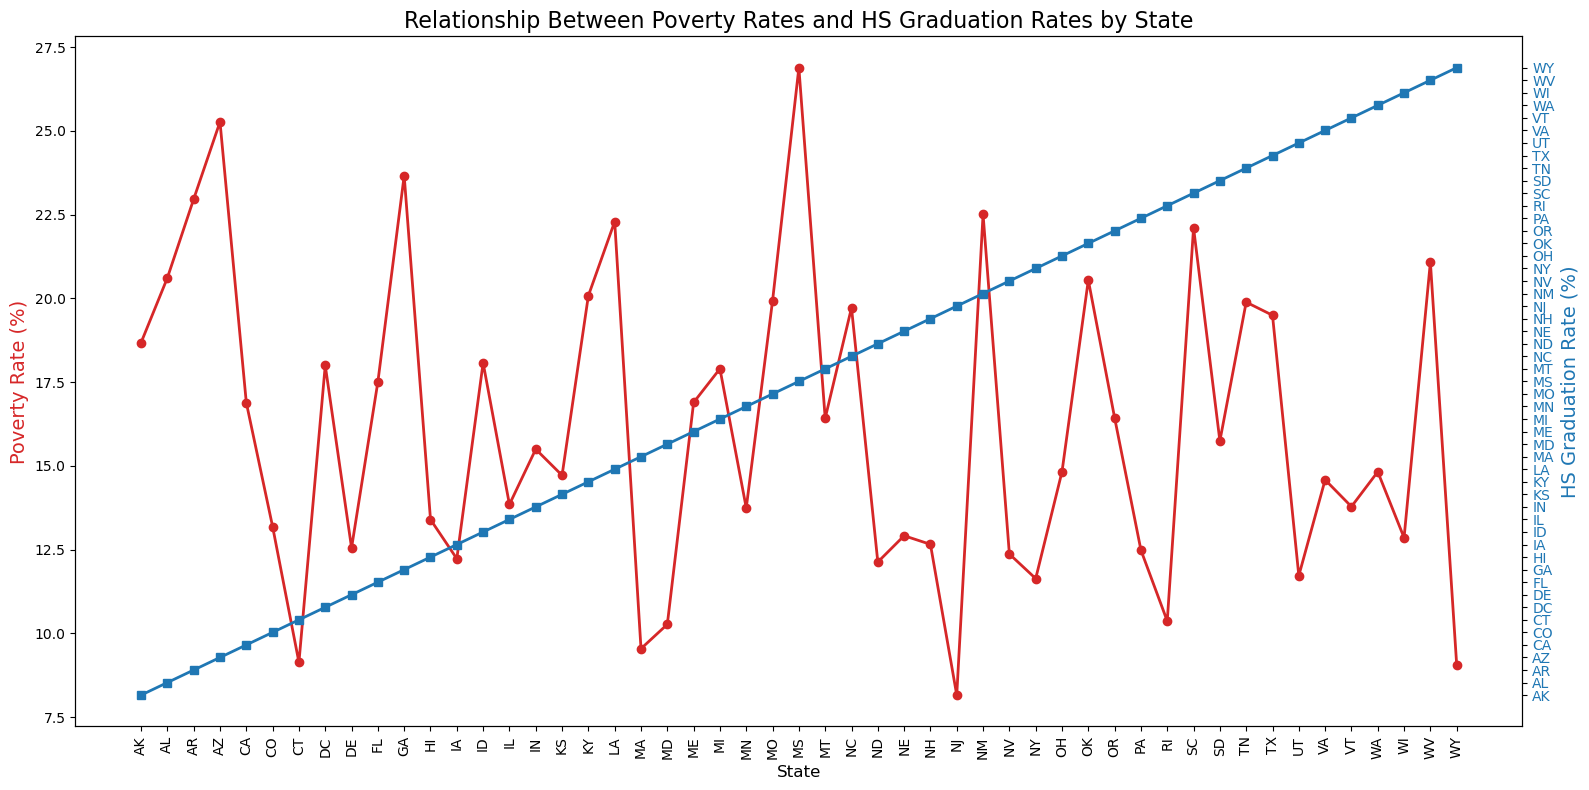

In [64]:
#plotting with two Y axis
fig,ax1 = plt.subplots(figsize = (16,8))

#axis of poverty line(red line)
ax1.set_xlabel('State',fontsize = 12)
ax1.set_ylabel('Poverty Rate (%)',color = 'tab:red',fontsize = 14)
ax1.plot(state_poverty.index,
         state_poverty.values,
         color = 'tab:red',
         marker = 'o',
         linewidth = 2,
         label = 'Poverty_rate')

#High school graduation rate (Blue Color)
ax2 = ax1.twinx()
ax2.set_ylabel('HS Graduation Rate (%)', color='tab:blue', fontsize=14)
ax2.plot(states_hs_grad.index,
         states_hs_grad.index,
         color = 'tab:blue',
         marker = 's',
         linewidth = 2,
         label = 'HS Graduation Rate')
ax2.tick_params(axis = 'y',
                labelcolor = 'tab:blue')

#styling
plt.title('Relationship Between Poverty Rates and HS Graduation Rates by State', fontsize=16)
ax1.set_xticks(range(len(state_poverty.index)))
ax1.set_xticklabels(state_poverty.index,rotation = 90)
fig.tight_layout()
plt.show()


#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [ ]:
#A jointplot() is  allows  to see the correlation between the two variables in the center while simultaneously viewing the distribution of each individual variable on the margins.

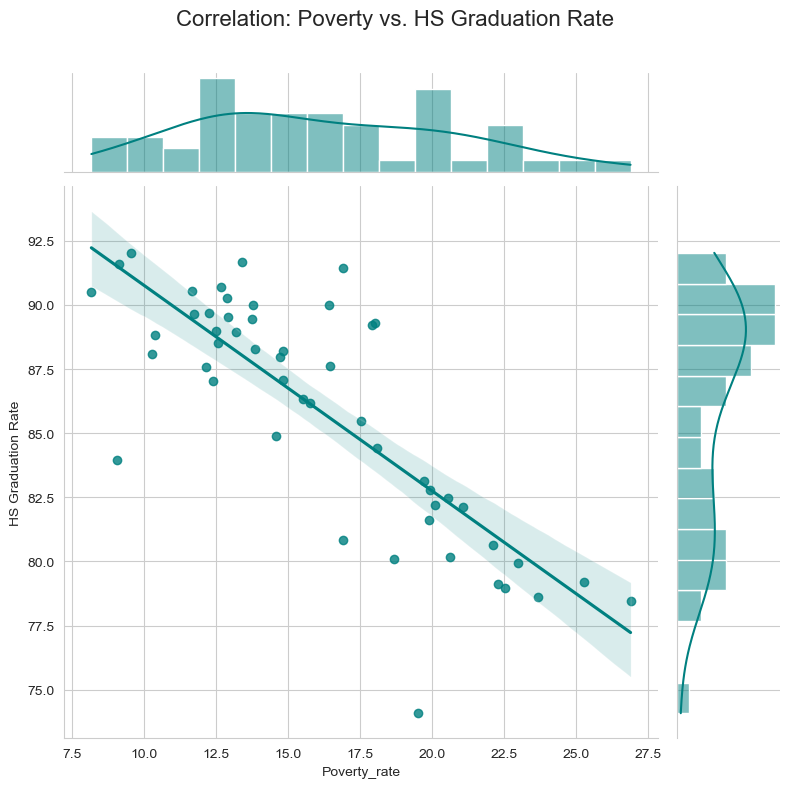

In [67]:
#combine  two series in single dataframe
relation_df = pd.DataFrame({
    'Poverty_rate':state_poverty,
    'HS Graduation Rate':states_hs_grad
})

sns.set_style('whitegrid')
g = sns.jointplot(data = relation_df,
                  x = 'Poverty_rate',
                  y = 'HS Graduation Rate',
                  kind='reg',
                  color = 'teal',
                  height=8,
                  marginal_kws=dict(bins = 15,fill = True))#this adds a scatter plot + reggression line + KDE on margin

g.fig.suptitle('Correlation: Poverty vs. HS Graduation Rate', fontsize=16)
g.fig.tight_layout()
g.fig.subplots_adjust(top = 0.9)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

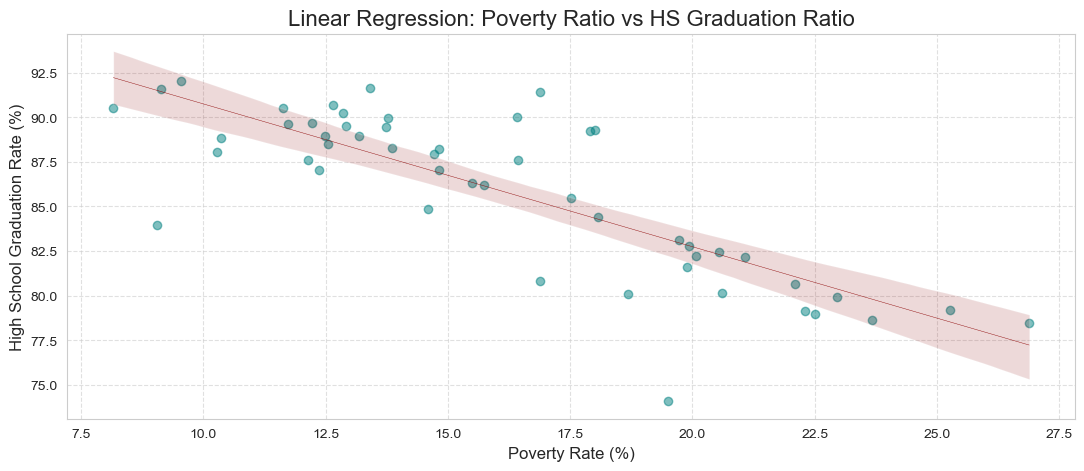

In [70]:
plt.figure(figsize=(13,5))

sns.regplot(
    data=relation_df,
    x = 'Poverty_rate',
    y = 'HS Graduation Rate',
    scatter_kws={'alpha':0.5,'color':'teal'},#transparents the plot
    line_kws={'color':'darkred','lw':0.3}
)

plt.title('Linear Regression: Poverty Ratio vs HS Graduation Ratio', fontsize=16)
plt.xlabel('Poverty Rate (%)', fontsize=12)
plt.ylabel('High School Graduation Rate (%)', fontsize=12)

plt.grid(True,linestyle = '--',alpha = 0.6)

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [72]:
#DATA CLEANING PROCESSORS
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col],errors='coerce')

state_race_share = df_share_race_city.groupby('Geographic area')[race_cols].mean().sort_index()

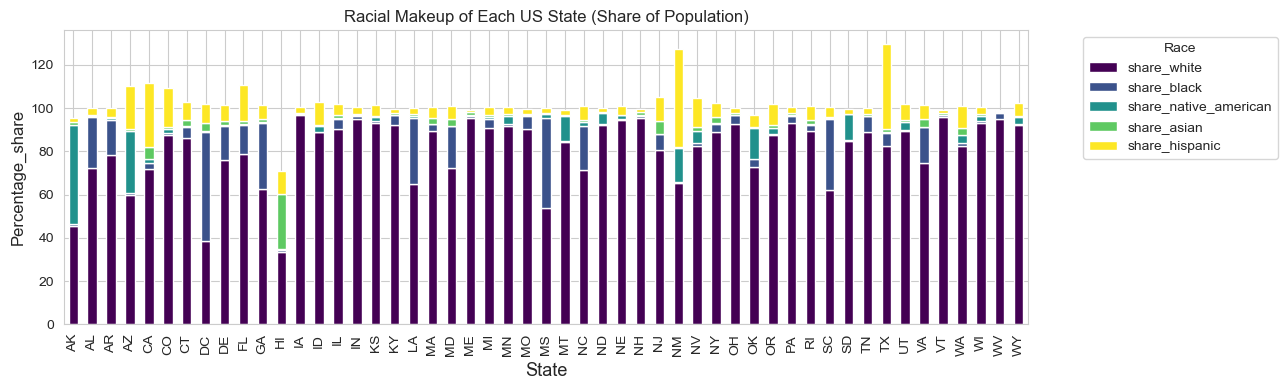

In [ ]:
#plotting stacked bar 
state_race_share.plot(kind='bar',
                      stacked=True,
                      figsize = (13,4),
                      colormap='viridis')

plt.title('Racial Makeup of Each US State (Share of Population)',fontsize = 12)
plt.xlabel('State',fontsize = 13)
plt.ylabel('Percentage_share',fontsize = 12)
plt.xticks(rotation = 90)
plt.legend(title = 'Race',bbox_to_anchor = (1.05,1),loc = 'upper left')#Legend ko upper move krna

plt.tight_layout()
plt.show()


# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [75]:
race_count = df_fatalities['race'].value_counts()

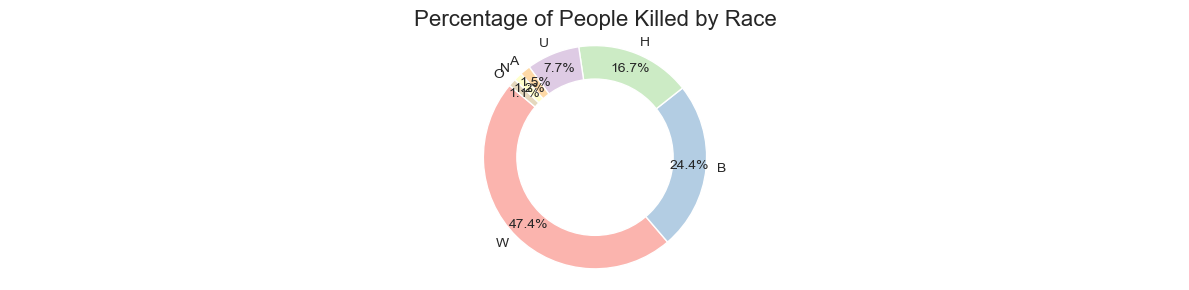

In [77]:
plt.figure(figsize = (12,3))
plt.pie(race_count.values,
        labels = race_count.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors,
        pctdistance=0.85)#to move per% outside

#for donate effect
centre_circle = plt.Circle((0,0),0.70,fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


plt.axis('equal')
plt.title('Percentage of People Killed by Race',fontsize = 16)
plt.tight_layout()
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [78]:
gender_count = df_fatalities['gender'].value_counts()

C:\Users\divya\AppData\Local\Temp\ipykernel_17024\2531416663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = gender_count.index,


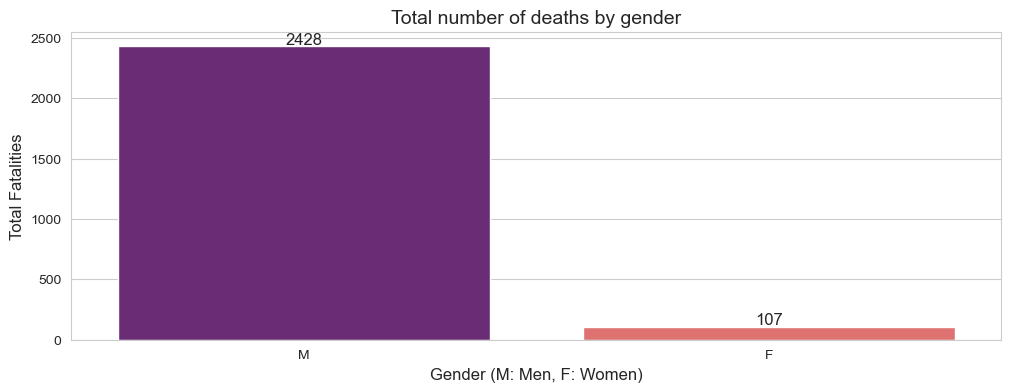

In [82]:
plt.figure(figsize=(12,4))
sns.barplot(x = gender_count.index,
            y = gender_count.values,
            palette='magma')
plt.title('Total number of deaths by gender',fontsize = 14)
plt.xlabel('Gender (M: Men, F: Women)',fontsize = 12)
plt.ylabel('Total Fatalities',fontsize = 12)

for i, count in enumerate(gender_count.values):
    plt.text(i, count + 20,str(count),ha = 'center',fontsize = 12,fontweight = 12)

plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).